### Using LangGraph

In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [ ]:
# define State

class BMIState(TypedDict):

    weight_kg : float
    height_m : float
    bmi : float
    category : str


In [5]:
def calculator_bmi(state:BMIState )-> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height**2)        # Formula for BMI Calculator

    state['bmi']=round(bmi,2)

    return state

In [9]:
def label_bmi(state : BMIState)->BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [15]:
# define the Graph
graph = StateGraph(BMIState)

# define the Nodes
graph.add_node('calculator_bmi',calculator_bmi)
graph.add_node('label_bmi',label_bmi)

# define the edges
graph.add_edge(START,'calculator_bmi')
graph.add_edge('calculator_bmi','label_bmi')
graph.add_edge('label_bmi',END)

# compile the graph
workflow = graph.compile()


In [16]:
# execution of the graph
initial_state = {'weight_kg':80,'height_m':1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


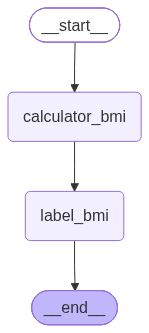

In [17]:
# For showing your graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())